# Week 10 — Computer Vision with Convolutional Neural Networks

## Day 1 — Session 2: Building Our First CNN with PyTorch

**Duration:** 90 minutes

**Main Theme:** From convolution mathematics to a working image-classification model

---

## Learning Objectives

By the end of this session, students should be able to:

1. Explain the role of `Conv2d`, `ReLU`, `MaxPool2d`, `Flatten`, and `Linear`.
2. Calculate the shape of tensors as they pass through a CNN.
3. Calculate the number of learnable parameters in a convolutional layer.
4. Build a simple CNN using PyTorch.
5. Load and preprocess the CIFAR-10 dataset.
6. Understand the basic PyTorch training loop for a CNN.
7. Observe and visualize intermediate feature maps.
8. Explain the intuition behind hierarchical feature extraction.

---

# Session Roadmap

```text
0–15 min    Review + CNN Shape Reasoning
15–30 min   Conv2d in PyTorch
30–45 min   Pooling
45–60 min   Build the Complete CNN
60–75 min   Train on CIFAR-10
75–90 min   Feature Map Visualization + Interpretation
```

---

# 1. Warm-Up: From Yesterday to Today

**Time: 0–15 minutes**

Yesterday we answered:

> Why do we need CNNs for images?

We introduced:

* Image as a tensor
* Kernel / Filter
* Feature Map
* Local Connectivity
* Parameter Sharing
* Stride
* Padding
* Receptive Field

Today we answer a different question:

> **How do we turn these mathematical ideas into an actual neural network?**

---

# 2. The CNN Pipeline

A typical CNN can be represented as:

```text
Input Image
     ↓
Convolution
     ↓
Activation
     ↓
Pooling
     ↓
Convolution
     ↓
Activation
     ↓
Pooling
     ↓
Flatten
     ↓
Fully Connected Layer
     ↓
Prediction
```

In PyTorch, this becomes something like:

```python
nn.Conv2d(...)
nn.ReLU()
nn.MaxPool2d(...)
nn.Conv2d(...)
nn.ReLU()
nn.MaxPool2d(...)
nn.Flatten()
nn.Linear(...)
```

Today we will understand exactly what each layer does.

---

# 3. Warm-Up Question: What Is the Output Shape?

Suppose we have:

```text
Input:
3 × 32 × 32
```

and:

```python
nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)
```

Ask students:

> What is the output shape?

We know from yesterday:

$$
Output =
\left\lfloor
\frac{N+2P-K}{S}
\right\rfloor+1
$$

Therefore:

$$
\frac{32+2(1)-3}{1}+1
=32
$$

So the spatial dimensions remain:

$$
32\times32
$$

But there are now 16 feature maps.

Therefore:

$$
3\times32\times32
\rightarrow
16\times32\times32
$$

---

# 4. Why Does `out_channels=16` Mean 16 Feature Maps?

Consider:

```python
nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3
)
```

The input has three channels:

```text
Red
Green
Blue
```

A convolution filter must operate across **all input channels**.

Therefore, one filter has shape:

$$
3\times3\times3
$$

One filter produces **one output feature map**.

If we use 16 filters:

```text
16 filters
      ↓
16 feature maps
```

So:

```text
Input:
3 × 32 × 32

        ↓ Conv2d

Output:
16 × 32 × 32
```

---

# 5. Parameter Counting in Conv2d

This is an excellent connection to the neural-network parameter counting from earlier weeks.

Consider:

```python
nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3
)
```

Each filter has:

$$
3\times3\times3=27
$$

weights.

There are 16 filters:

$$
27\times16=432
$$

If every filter has one bias:

$$
432+16=448
$$

Therefore:

$$
\boxed{448\text{ parameters}}
$$

---

## Compare with Fully Connected

Suppose we flattened the same image:

$$
3\times32\times32=3072
$$

and connected it to 16 neurons.

The number of parameters would be:

$$
3072\times16+16
$$

$$
=49,168
$$

Compare:

```text
Fully Connected: 49,168 parameters
Convolution:         448 parameters
```

This is a powerful demonstration of why CNNs are parameter-efficient.

---

# 6. Important Concept: Channels vs Filters

Students often confuse these concepts.

### Input channels

Describe the information entering the layer.

Example:

```text
RGB image → 3 input channels
```

### Output channels

Correspond to the number of filters.

Example:

```text
16 filters → 16 output channels
```

Therefore:

```text
in_channels
    ↓
How many channels come in?

out_channels
    ↓
How many feature maps do we produce?
```

---

# 7. ReLU

**Time: 15–30 minutes**

After convolution, we usually apply an activation function.

The most common choice is:

$$
ReLU(x)=\max(0,x)
$$

For example:

$$
[-2,\ 3,\ -1,\ 5]
$$

becomes:

$$
[0,\ 3,\ 0,\ 5]
$$

---

## Why Do We Need ReLU?

This connects directly to Week 8.

Without nonlinear activation functions, stacking linear layers does not create a truly nonlinear model.

A CNN therefore typically uses:

```text
Convolution
      ↓
ReLU
```

rather than only:

```text
Convolution
      ↓
Convolution
      ↓
Convolution
```

---

# 8. First PyTorch Building Block

In [1]:
import torch
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

relu = nn.ReLU()

We can create a random batch:

In [2]:
x = torch.randn(8, 3, 32, 32)


The shape means:

```text
8 images
3 channels
32 height
32 width
```

In [3]:
y = conv(x)
print(y.shape)


torch.Size([8, 16, 32, 32])


Then:

In [4]:
y = relu(y)
print(y.shape)


torch.Size([8, 16, 32, 32])


The shape does not change:

ReLU changes values, not dimensions.

---

# 9. Pooling

**Time: 30–45 minutes**

The next important component is **pooling**.

The main idea:

> Reduce spatial dimensions while keeping important information.

The most common operation is:

```python
nn.MaxPool2d(kernel_size=2)
```

Suppose:

```text
16 × 32 × 32
```

After:

```python
nn.MaxPool2d(2)
```

we get:

```text
16 × 16 × 16
```

Notice:

* Number of channels stays the same.
* Height is divided by 2.
* Width is divided by 2.

---

# 10. How Does Max Pooling Work?

Consider:

$$
\begin{bmatrix}
1&5\\
3&2
\end{bmatrix}
$$

Max pooling selects:

$$
\max(1,5,3,2)=5
$$

So:

```text
1  5
3  2
```

becomes:

```text
5
```

---

## Example

Consider:

$$
\begin{bmatrix}
1&3&2&4\\
5&6&1&2\\
7&2&9&3\\
4&8&5&1
\end{bmatrix}
$$

Using:

$$
2\times2
$$

max pooling with stride 2:

Top-left:

$$
\max
\begin{bmatrix}
1&3\\
5&6
\end{bmatrix}
=6
$$

Top-right:

$$
\max
\begin{bmatrix}
2&4\\
1&2
\end{bmatrix}
=4
$$

Bottom-left:

$$
\max
\begin{bmatrix}
7&2\\
4&8
\end{bmatrix}
=8
$$

Bottom-right:

$$
\max
\begin{bmatrix}
9&3\\
5&1
\end{bmatrix}
=9
$$

Result:

$$
\begin{bmatrix}
6&4\\
8&9
\end{bmatrix}
$$

---

# 11. Why Reduce Spatial Dimensions?

Suppose we have:

```text
32 × 32
```

and then:

```text
16 × 16
```

We have fewer spatial positions.

This means:

* Less computation
* Fewer activations
* Larger effective receptive fields in deeper layers
* Some robustness to small translations

Conceptually:

```text
High Resolution
      ↓
Pooling
      ↓
Lower Resolution
      ↓
More Abstract Representation
```

---

# 12. Max Pooling vs Average Pooling

Another option is:

```python
nn.AvgPool2d(2)
```

Max pooling:

$$
\max(x_1,x_2,\dots,x_n)
$$

Average pooling:

$$
\frac{x_1+x_2+\dots+x_n}{n}
$$

Intuitively:

### Max Pooling

> "Is this feature strongly present anywhere in this region?"

### Average Pooling

> "What is the average activation in this region?"

For today's CNN we will use **Max Pooling**.

---

# 13. Building the Architecture

**Time: 45–60 minutes**

Now let's combine what we have learned.

Our first CNN:

```text
Input
  ↓
Conv2d
  ↓
ReLU
  ↓
MaxPool
  ↓
Conv2d
  ↓
ReLU
  ↓
MaxPool
  ↓
Flatten
  ↓
Linear
  ↓
Output
```

We will use CIFAR-10.

---

# 14. CIFAR-10

CIFAR-10 contains:

$$
60,000
$$

color images belonging to 10 classes.

The classes are:

```text
airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck
```

Each image has:

$$
32\times32\times3
$$

---

# 15. CIFAR-10 Dataset in PyTorch


In [5]:
import torch
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

```

---

# 16. DataLoader

Instead of processing all 50,000 training images simultaneously, we use mini-batches.

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

```

The training pipeline becomes:

```text
Dataset
   ↓
DataLoader
   ↓
Mini-batch
   ↓
CNN
   ↓
Loss
   ↓
Backpropagation
   ↓
Optimizer
```

This directly connects to the training concepts from Week 9.

---

# 17. Designing the CNN

Let's create:

In [7]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Now let's understand **why `32 * 8 * 8` appears**.

---

# 18. Shape Tracking — The Most Important Exercise

Start:

```text
Input
3 × 32 × 32
```

### First Conv

```python
nn.Conv2d(3, 16, 3, padding=1)
```

Spatial dimensions stay the same:

```text
16 × 32 × 32
```

### First Pooling

```python
nn.MaxPool2d(2)
```

Therefore:

```text
16 × 16 × 16
```

### Second Conv

```python
nn.Conv2d(16, 32, 3, padding=1)
```

Output:

```text
32 × 16 × 16
```

### Second Pooling

```text
32 × 8 × 8
```

Therefore:

$$
32\times8\times8=2048
$$

After flattening:

```text
2048
```

So:

```python
nn.Linear(2048, 10)
```

---

# 19. Complete Shape Diagram

Put this on the board:

```text
Input
[B, 3, 32, 32]
       ↓
Conv2d(3 → 16)
[B, 16, 32, 32]
       ↓
ReLU
[B, 16, 32, 32]
       ↓
MaxPool(2)
[B, 16, 16, 16]
       ↓
Conv2d(16 → 32)
[B, 32, 16, 16]
       ↓
ReLU
[B, 32, 16, 16]
       ↓
MaxPool(2)
[B, 32, 8, 8]
       ↓
Flatten
[B, 2048]
       ↓
Linear
[B, 10]
```

This diagram should be emphasized because understanding tensor shapes is one of the most important practical CNN skills.

---

# 20. What Does the Output Mean?

The final layer produces:

$$
10
$$

numbers.

For example:

```text
[1.2, -0.4, 3.8, 0.2, ..., -1.1]
```

These are **logits**.

The largest logit corresponds to the model's predicted class.

For example:

```text
airplane     1.2
automobile  -0.4
bird         3.8  ← highest
cat          0.2
...
```

Prediction:

> Bird

During training we use:

```python
nn.CrossEntropyLoss()
```

We do **not** need to apply softmax manually before `CrossEntropyLoss`.

---

# 21. Creating the Model

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCNN().to(device)

print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=10, bias=True)
  )
)


If a GPU is available:

```text
Model → GPU
```

Otherwise:

```text
Model → CPU
```

---

# 22. Loss Function and Optimizer

**Time: 60–75 minutes**

Now connect this to Week 9.

We need:

### Loss

In [9]:
criterion = nn.CrossEntropyLoss()

### Optimizer

For example:

In [10]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


The complete training components are:

```text
Model
 +
Loss Function
 +
Optimizer
 =
Trainable Neural Network
```

---

# 23. The Training Loop

A simplified training loop:

In [11]:
for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)

    # Compute loss
    loss = criterion(outputs, labels)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

This is exactly the training process students learned in Weeks 8 and 9.

The only major difference is the architecture of the model.

---

# 24. Explain Every Step

### Step 1 — Forward Pass

```python
outputs = model(images)
```

The image travels through:

```text
Image
 ↓
Conv
 ↓
ReLU
 ↓
Pool
 ↓
Conv
 ↓
ReLU
 ↓
Pool
 ↓
Linear
 ↓
Logits
```

---

### Step 2 — Loss

```python
loss = criterion(outputs, labels)
```

We compare:

```text
Prediction
    vs
True Label
```

---

### Step 3 — Clear Gradients

```python
optimizer.zero_grad()
```

PyTorch accumulates gradients by default.

Therefore, we clear them before calculating the new gradients.

---

### Step 4 — Backpropagation

```python
loss.backward()
```

Calculate:

$$
\frac{\partial L}{\partial W}
$$

for the model parameters.

---

### Step 5 — Update Parameters

```python
optimizer.step()
```

The optimizer updates the weights.

Conceptually:

$$
W_{new}
= W_{old}-
\eta
\nabla_W L
$$

---

# 25. A Complete Training Function

In [12]:


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


The important point is not memorizing this function.

Students should understand the flow:

```text
Data
 ↓
Forward
 ↓
Loss
 ↓
Backward
 ↓
Update
```

---

# 26. Evaluation

During evaluation we do not update the weights.

In [13]:
def evaluate(model, loader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    return correct / total


```

The key difference:

```text
Training:
model.train()
gradients enabled
weights updated

Evaluation:
model.eval()
no gradients
weights NOT updated
```

---

# 27. What Should We Expect?

Don't promise a specific accuracy.

Instead, observe:

```text
Epoch 1
Epoch 2
Epoch 3
...
```

and record:

```text
Training Loss
Training Accuracy
Validation/Test Accuracy
```

A typical learning curve might look conceptually like:

```text
Loss
│\
│ \
│  \
│   \
│    \____
│
└────────────── Epoch
```

The goal today is not to build a state-of-the-art CIFAR-10 classifier.

The goal is:

> **Understand the complete CNN training pipeline.**

---

# 28. Feature Maps — Open the Black Box

**Time: 75–90 minutes**

We now have a working CNN.

But a natural question is:

> What does the CNN actually see?

Instead of only looking at the final prediction, let's inspect intermediate feature maps.

Consider:

```text
Input Image
    ↓
First Conv Layer
    ↓
Feature Maps
```

These feature maps represent the response of different learned filters.

---

# 29. Extracting Feature Maps

We can modify the model slightly:

In [14]:
def forward_features(self, x):

    x = self.features[0](x)

    return x


Or simply inspect intermediate activations during a forward pass.

For example:

In [15]:
with torch.no_grad():

    x = images[:1].to(device)

    conv1_output = model.features[0](x)

print(conv1_output.shape)

torch.Size([1, 16, 32, 32])


Expected:

```text
[1, 16, 32, 32]
```

That means:

> One image produced 16 feature maps.

---

# 30. Visualizing Feature Maps

A simple visualization:

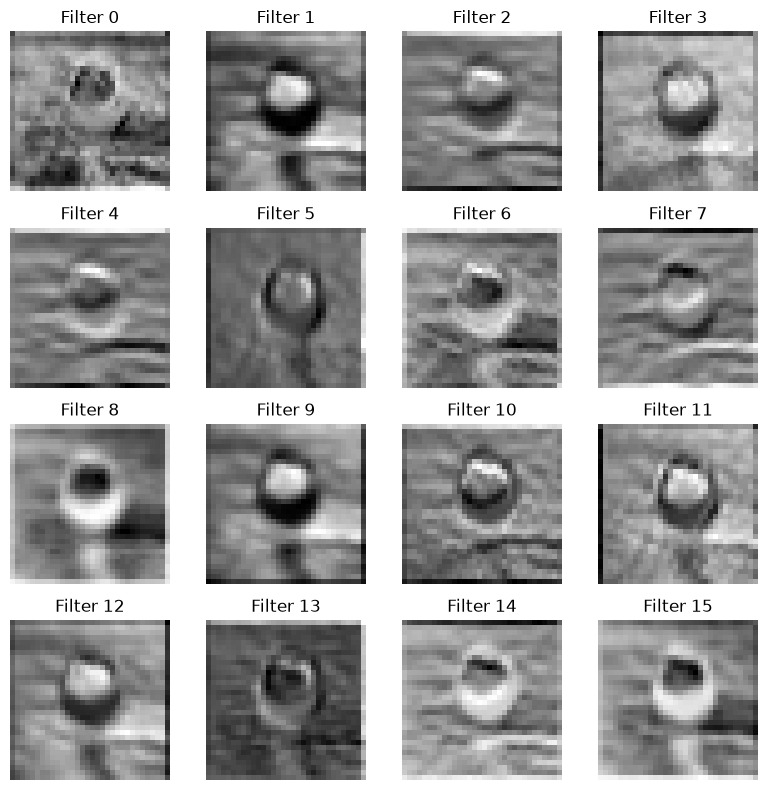

In [16]:
import matplotlib.pyplot as plt

feature_maps = conv1_output[0].cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feature_maps[i],
        cmap="gray"
    )

    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

You can observe that different filters produce different activation patterns.

Some may respond strongly to:

* edges
* textures
* local shapes
* boundaries

---

# 31. Important Warning About Feature Visualization

Do **not** tell:

> "Filter 1 is definitely the vertical-edge detector."

That interpretation is often too simplistic.

The correct statement is:

> Early convolutional filters often learn simple visual patterns such as edges, orientations, textures, or color transitions.

The actual learned representation depends on:

* Dataset
* Architecture
* Initialization
* Training
* Optimization

---

# 32. Hierarchical Feature Learning

This gives us one of the most important ideas in deep learning for vision.

### Early layers

```text
Edges
Color transitions
Simple textures
```

### Middle layers

```text
Contours
Patterns
Shapes
```

### Deeper layers

```text
Object parts
Complex structures
Semantic representations
```

Conceptually:

```text
              CNN
               │
      ┌────────┴────────┐
      │                 │
  Low-level          High-level
  features            features
      │                 │
      ↓                 ↓
   Edges → Textures → Shapes → Parts → Objects
```

---

# 33. The Complete Picture

We can now connect everything from yesterday and today.

```text
                   IMAGE
                     │
                     ▼
              Local Patterns
                     │
                     ▼
                Convolution
                     │
                     ▼
                  ReLU
                     │
                     ▼
                 Pooling
                     │
                     ▼
            More Complex Features
                     │
                     ▼
                Convolution
                     │
                     ▼
                  ReLU
                     │
                     ▼
                 Pooling
                     │
                     ▼
                  Flatten
                     │
                     ▼
              Fully Connected
                     │
                     ▼
                  Logits
                     │
                     ▼
                Prediction
```

During training:

```text
Prediction
    ↓
Loss
    ↓
Backpropagation
    ↓
Gradient
    ↓
Optimizer
    ↓
Updated Filters
    ↓
Better Features
```

---

# 34. Key Takeaways

By the end of today's session, students should remember:

### 1. CNNs exploit spatial structure

They don't treat an image as an arbitrary long vector.

### 2. Convolution uses local connectivity

A filter looks at a small region.

### 3. Filters are learned

The network discovers useful visual patterns through training.

### 4. Parameter sharing makes CNNs efficient

The same filter is reused across different spatial locations.

### 5. Pooling reduces spatial dimensions

It helps create compact representations.

### 6. CNNs learn hierarchical features

```text
Edges
 ↓
Textures
 ↓
Shapes
 ↓
Parts
 ↓
Objects
```

### 7. CNN training is still standard deep learning

```text
Forward
 ↓
Loss
 ↓
Backward
 ↓
Optimizer
```

The training principles from Week 9 still apply.

---

# 35. In-Class Exercises

## Exercise 1 — Shape Tracking

Given:

```text
Input: 3 × 32 × 32
```

and:

```python
Conv2d(3, 16, kernel_size=3, padding=1)
MaxPool2d(2)
Conv2d(16, 32, kernel_size=3, padding=1)
MaxPool2d(2)
```

Ask students to calculate the shape after every layer.

Expected:

```text
Input
3 × 32 × 32

Conv
16 × 32 × 32

Pool
16 × 16 × 16

Conv
32 × 16 × 16

Pool
32 × 8 × 8
```

---

# 36. Exercise 2 — Parameter Counting

Calculate the number of parameters in:

```python
nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=3
)
```

Formula:

$$
Parameters =
(K_H\times K_W\times C_{in})C_{out}
+
C_{out}
$$

Therefore:

$$
(3\times3\times16)\times32+32
$$

$$
=4608+32
$$

$$
=\boxed{4640}
$$

---

# 37. Exercise 3 — Modify the CNN

Ask students to change:

```python
nn.Conv2d(3, 16, 3, padding=1)
```

to:

```python
nn.Conv2d(3, 32, 3, padding=1)
```

Then ask:

1. What happens to the number of feature maps?
2. What happens to the number of parameters?
3. What happens to the shape of the next layer?
4. Does the final `Linear` layer need to change?

This is an excellent practical exercise because students must reason about tensor shapes rather than simply copy code.

---

# 38. Homework

## Task 1 — Architecture Reasoning

Design a CNN for CIFAR-10 with:

* At least two convolutional layers
* ReLU after each convolution
* At least two pooling operations
* One fully connected classification layer

Draw the architecture as:

```text
Input
 ↓
?
 ↓
?
 ↓
?
 ↓
Output
```

For every layer, write the tensor shape.

---

## Task 2 — Experiment

Change:

```python
out_channels=16
```

to:

```python
out_channels=32
```

Compare:

* Number of parameters
* Training time
* Training accuracy
* Test accuracy

Then answer:

> Does doubling the number of filters necessarily double the model's performance?

---

## Task 3 — Think

Answer in your own words:

> Why is the same filter useful at multiple locations in an image?

---

# 39. Preview of Day 2 — Session 3

Our CNN now works.

But there is a new problem.

Suppose we observe:

```text
Training Accuracy:   95%
Validation Accuracy: 70%
```

What happened?

The model has likely **overfit**.

Tomorrow we will use the concepts from Week 9 to improve our CNN:

```text
Baseline CNN
      ↓
Weight Decay
      ↓
Dropout
      ↓
Data Augmentation
      ↓
Learning Rate Scheduling
      ↓
Better Generalization
```

The key question for the next session will be:

> **How can we make our CNN perform well not only on the training images, but also on images it has never seen before?**